## **Setup**

In [1]:
import os, sys

# Repository information
REPO_NAME = "RecSys-Challenge-2025"
REPO_URL  = f"github.com/Lv1g1/{REPO_NAME}.git"

# Detect environment
IS_COLAB = 'content' in os.getcwd()
IS_KAGGLE = 'kaggle' in os.getcwd()
IS_LOCAL = not (IS_COLAB or IS_KAGGLE)

WORKING_DIR = os.getcwd()

if IS_COLAB:
    WORKING_DIR = "/content"

    # Mount Google Drive
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)

    # Get GitHub token via input
    def get_token():
        from getpass import getpass
        return getpass("GitHub Token: ")

elif IS_KAGGLE:
    WORKING_DIR = "/kaggle/working"

    # Get GitHub token from Kaggle secrets
    def get_token():
        from kaggle_secrets import UserSecretsClient
        return UserSecretsClient().get_secret("Token")

# If local environment assume inside the repo
LOCAL_REPO_PATH = "/home/luigi/RecSys" if IS_LOCAL else os.path.join(WORKING_DIR, REPO_NAME)

# Clone the repository if it doesn't exist
if not os.path.exists(LOCAL_REPO_PATH):
    os.chdir(WORKING_DIR)
    token = get_token()

    !git clone https://{token}@{REPO_URL}
else:
    print("Repo already exists — pulling latest changes")
    os.chdir(LOCAL_REPO_PATH)
    !git pull
    os.chdir(WORKING_DIR)

# Add to Python PATH
if LOCAL_REPO_PATH not in sys.path:
    sys.path.append(LOCAL_REPO_PATH)

if IS_COLAB:
    !pip install optuna

Repo already exists — pulling latest changes
Already up to date.


In [2]:
if IS_COLAB or False:  # Set to True if you want to recompile Cython files
    os.chdir(LOCAL_REPO_PATH)
    !python run_compile_all_cython.py
    os.chdir(WORKING_DIR)

## **Imports**

In [3]:
import os
import pandas as pd
import numpy as np
from xgboost import XGBRanker
from xgboost import plot_importance
from sklearn.metrics import roc_auc_score

from Challenge.paths import load_holdout_split, XGBOOST_DATAFRAMES
from Challenge.utils import evaluate_recommender_xgboost
from Challenge.XGBoostReranker import XGBoostRerankerRecommender, ProgressCallback

Running on local — storage at: /home/luigi/RecSys


## **Load Data**

In [4]:
np.random.seed(0xbeef)

In [5]:
_, URM_outer = load_holdout_split()

In [6]:
file_path = os.path.join(XGBOOST_DATAFRAMES, "training_OOF.parquet")

X_train_full = pd.read_parquet(
    file_path,
    engine='fastparquet'
)

print(f"Loaded successfully from: {file_path}")
X_train_full

Loaded successfully from: /home/luigi/RecSys/xg_boost_data/dataframes/training_OOF.parquet


,UserID,ItemID,top_10,top_20,top_30,top_40,top_50,Label,EASE_R_Score,EASE_R_RankPosition,...,User_to_ItemCluster_Dist,Mean_RankPosition,Std_RankPosition,Min_RankPosition,Mean_Score,Std_Score,Max_Score,User_Profile_Len,Item_Global_Popularity,User_Avg_Item_Popularity
0,0,13,0,0,0,0,0,0,0.146634,106,...,2.763314,646,539,59,0.084832,0.081167,0.221003,77,413,1541.376587
1,0,5706,0,0,0,1,1,0,0.180238,58,...,2.756729,827,1427,10,0.191343,0.202138,0.577017,72,485,1429.055542
2,0,5766,0,0,1,1,1,0,0.305060,16,...,2.756729,351,1050,16,0.273811,0.139576,0.503647,72,2895,1429.055542
3,0,5830,0,0,0,0,0,0,0.162575,75,...,2.777495,412,1056,20,0.230950,0.167745,0.525276,72,1731,1429.055542
4,0,5956,0,0,0,0,0,0,0.241022,31,...,2.803360,43,47,10,0.289829,0.098583,0.472416,72,1454,1429.055542
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23176689,27094,640,0,0,0,1,1,0,0.275289,76,...,4.523964,84,51,17,0.359248,0.152304,0.757386,221,2377,874.778259
23176690,27094,797,0,0,0,0,0,0,0.247680,96,...,4.458327,214,356,19,0.349893,0.228300,0.704917,221,615,874.778259
23176691,27094,868,0,0,0,0,0,0,0.316601,55,...,4.585932,706,1181,48,0.239673,0.137379,0.441403,221,6416,874.778259
23176692,27094,101,0,0,0,0,0,0,0.396964,33,...,4.503058,67,64,7,0.413890,0.196016,0.665027,221,576,818.176453


In [7]:
if not X_train_full['UserID'].is_monotonic_increasing:
    print("⚠️ Data is NOT sorted by UserID.")
    print("Sorting and overwriting file for future efficiency...")
    
    # Sort and reset index (critical for contiguous memory in ML)
    X_train_full = X_train_full.sort_values(by='UserID').reset_index(drop=True)
    
    # Overwrite the file on disk
    X_train_full.to_parquet(
        path=file_path,
        engine='fastparquet',
        compression='snappy',
        index=False
    )
    
    print(f"✅ Data sorted and saved to {file_path}")

In [8]:
N_USERS_TO_SAMPLE = 3000

# Get all unique users
all_unique_users = X_train_full['UserID'].unique()

# Pick 3,000 random users
# We sort them so the resulting matrices remain in ID order (0, 5, 10...) 
# rather than random order (10, 0, 5...). This prevents confusion later.
selected_users = np.sort(np.random.choice(all_unique_users, size=N_USERS_TO_SAMPLE, replace=False))

print(f"Subsampling: Selected {len(selected_users)} users out of {len(all_unique_users)}")

# Filter the DataFrame to keep ONLY these users
X_train_sub = X_train_full[X_train_full['UserID'].isin(selected_users)].copy()

# CRITICAL: Re-sort by UserID and ItemID so groups remain contiguous
X_train_sub = X_train_sub.sort_values(by=['UserID', 'ItemID']).reset_index(drop=True)

print(f"Data reduced from {len(X_train_full)} rows to {len(X_train_sub)} rows.")

Subsampling: Selected 3000 users out of 27095
Data reduced from 23176694 rows to 2565024 rows.


In [9]:
# -------------------------------------------------------------------------
# 4. Prepare XGBoost Inputs on the SUBSET
# -------------------------------------------------------------------------

assert X_train_sub['UserID'].is_monotonic_increasing, "Training set is not sorted by UserID!"

# Group Calculation (Must be done on the subset)
groups = X_train_sub.groupby("UserID").size().values

# Target
y_train = X_train_sub["Label"]

# Drop metadata to create Feature Matrix
X_train = X_train_sub.drop(columns=["Label", "UserID", "ItemID"], errors='ignore')

# Categorical handling
for col in ['User_Cluster', 'Item_Cluster', 'Cluster_Interaction']:
    if col in X_train.columns:
        X_train[col] = X_train[col].astype('category')

assert groups.sum() == X_train.shape[0], "Group sum mismatch!"

In [10]:
file_path = os.path.join(XGBOOST_DATAFRAMES, "validation_OOF.parquet")

X_val = pd.read_parquet(
    file_path,
    engine='fastparquet'
)

# Make categorical features if any
for col in ['User_Cluster', 'Item_Cluster', 'Cluster_Interaction']:
    X_val[col] = X_val[col].astype('category')

print(f"Loaded successfully from: {file_path}")
X_val

Loaded successfully from: /home/luigi/RecSys/xg_boost_data/dataframes/validation_OOF.parquet


,UserID,ItemID,top_10,top_20,top_30,top_40,top_50,SLIMElasticNet_Score,SLIMElasticNet_RankPosition,MultVAE_Score,...,User_to_ItemCluster_Dist,Mean_RankPosition,Std_RankPosition,Min_RankPosition,Mean_Score,Std_Score,Max_Score,User_Profile_Len,Item_Global_Popularity,User_Avg_Item_Popularity
0,0,86,0,0,0,0,0,0.158978,80,0.457685,...,2.869778,381,776,37,0.191037,0.131878,0.457685,80,3378,1710.587524
1,0,227,0,0,1,1,1,0.230409,33,0.449216,...,2.907956,691,1101,12,0.259972,0.192477,0.596722,80,2310,1710.587524
2,0,275,0,0,0,0,0,0.061567,283,0.457007,...,2.855224,81,80,21,0.263086,0.149934,0.485854,80,1043,1710.587524
3,0,282,0,0,0,1,1,0.182080,58,0.356088,...,2.841163,100,116,7,0.260711,0.181357,0.626083,80,1819,1710.587524
4,0,291,0,0,0,0,0,0.119798,132,0.373464,...,2.869778,324,746,13,0.220234,0.139970,0.415816,80,2854,1710.587524
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2296113,27094,6328,0,0,0,1,1,0.115149,263,0.577463,...,4.539614,78,72,11,0.379431,0.228762,0.806681,250,213,933.643982
2296114,27094,6516,0,1,1,1,1,0.448237,16,0.432170,...,4.409982,463,1333,14,0.406694,0.234251,0.685544,250,2956,933.643982
2296115,27094,6620,0,0,0,0,0,0.311993,56,0.289841,...,4.494019,313,248,56,0.237791,0.118687,0.424300,250,396,933.643982
2296116,27094,6724,0,0,0,0,1,0.147140,199,0.557740,...,4.494019,204,240,17,0.315344,0.215339,0.724451,250,225,933.643982


In [11]:
# Reorder val columns to match training set
feature_cols = [c for c in X_train.columns if c != 'Label'] + ['UserID', 'ItemID']
X_val = X_val[feature_cols]

# Subset validation to selected users only
X_val = X_val[X_val['UserID'].isin(selected_users)]

assert X_val['UserID'].is_monotonic_increasing, "Validation set is not sorted by UserID!"

In [12]:
# 2. Extract Labels from URM_outer (The "Lookup")
# We use fancy indexing on the sparse matrix to get values fast
# URM_outer is (N_Users, N_Items). We want the value at [User, Item] for every row in X_val.
print("Extracting Ground Truth labels from URM_outer...")

# Ensure UserID and ItemID are integers for indexing
val_user_ids = X_val['UserID'].values
val_item_ids = X_val['ItemID'].values

# SCIPY TRICK: URM[rows, cols] returns a matrix of values for those specific pairs
# We convert it to a dense numpy array immediately
# Note: This requires URM_outer to be a CSR or CSC matrix
y_val = np.array(URM_outer[val_user_ids, val_item_ids]).squeeze()

# If URM is binary, y_val is now 0s and 1s. 
# If URM has ratings (1-5), y_val has ratings. For ranking, we usually want binary or weighted.
# Ensure it is 1D array
y_val = np.array(y_val).flatten()

print(f"Validation Labels created. Positive samples: {y_val.sum()} out of {len(y_val)}")

# 3. Calculate Validation Groups
# XGBoost needs to know how many rows belong to each user in the validation set
val_groups = X_val.groupby("UserID").size().values

# 4. Prepare Feature Matrix
# Drop IDs and Metadata, keep only training features
# We check X_train.columns to ensure we have the exact same columns
feature_cols_model = [c for c in X_train.columns] # X_train should already be dropped of metadata
X_val_features = X_val[feature_cols_model].copy()

# Double check shapes
assert len(X_val_features) == len(y_val)
assert val_groups.sum() == len(X_val_features)

print("Validation data ready for Early Stopping.")

Extracting Ground Truth labels from URM_outer...
Validation Labels created. Positive samples: 32098.0 out of 254046
Validation data ready for Early Stopping.


In [13]:
X_train.columns

Index(['top_10', 'top_20', 'top_30', 'top_40', 'top_50', 'EASE_R_Score',
       'EASE_R_RankPosition', 'SLIMElasticNet_Score',
       'SLIMElasticNet_RankPosition', 'MultVAE_Score', 'MultVAE_RankPosition',
       'MatrixFactorization_WARP_Score',
       'MatrixFactorization_WARP_RankPosition', 'IALS_Score',
       'IALS_RankPosition', 'RP3beta_Score', 'RP3beta_RankPosition',
       'P3alpha_Score', 'P3alpha_RankPosition', 'UserKNN_cosine_Score',
       'UserKNN_cosine_RankPosition', 'UserKNN_tversky_Score',
       'UserKNN_tversky_RankPosition', 'ItemKNN_cosine_Score',
       'ItemKNN_cosine_RankPosition', 'ItemKNN_tversky_Score',
       'ItemKNN_tversky_RankPosition', 'SLIMElasticNet_MaxSim',
       'SLIMElasticNet_MeanSim', 'SLIMElasticNet_StdSim',
       'SLIMElasticNet_MatchCount', 'RP3beta_MaxSim', 'RP3beta_MeanSim',
       'RP3beta_StdSim', 'RP3beta_MatchCount', 'User_Cluster', 'Item_Cluster',
       'Cluster_Interaction', 'User_Cluster_Dist', 'Item_Cluster_Dist',
       'User_to

In [14]:
# --- PREPARE MONITORING SUBSET ---
n_monitor_users = 1000

# 1. Slice the Groups
# We simply take the group sizes for the first 3k users
groups_subset = groups[:n_monitor_users]

# 2. Calculate total rows corresponding to those users
# Sum of the first 3k groups tells us where to cut the dataframe
n_rows_subset = groups_subset.sum()

# 3. Slice the Features and Labels
# Since data is sorted by UserID, the first N rows belong to the first M users.
X_train_subset = X_train.iloc[:n_rows_subset]
y_train_subset = y_train.iloc[:n_rows_subset]

print(f"Training Monitor: {len(groups_subset)} users ({len(X_train_subset)} rows)")
print(f"Validation Monitor: {len(val_groups)} users ({len(X_val_features)} rows)")

Training Monitor: 1000 users (854265 rows)
Validation Monitor: 3000 users (254046 rows)


## **Manual Optimization**

In [ ]:
# The "Sweet Spot" Configuration
n_estimators = 2000      # High capacity, but we rely on Early Stopping
learning_rate = 0.005    # Very Slow & Steady (Crucial for Rankers)
max_depth = 7            # The compromise. 7 was too dumb, 12 was too smart.
reg_alpha = 0.5          # High L1 to kill useless features
reg_lambda = 0.5         # High L2 to prevent one feature (SLIM) from dominating
min_child_weight = 1     # IMPORTANT: Stop looking at groups smaller than 10 users/items

# Breaking the Feature Dominance
colsample_bytree = 0.6   # Force it to explore weaker features (only sees 60% of features per tree)
subsample = 0.75         # Prevent overfitting to specific user groups
early_stopping_rounds=100

XGB_model = XGBRanker(
    objective='rank:ndcg',
    n_estimators=n_estimators,
    learning_rate=learning_rate,
    max_depth=max_depth,
    reg_alpha=reg_alpha,
    reg_lambda=reg_lambda,
    min_child_weight=min_child_weight,
    colsample_bytree=colsample_bytree,
    subsample=subsample,
    early_stopping_rounds=early_stopping_rounds,

    tree_method="hist",
    n_jobs=-1,
    
    random_state=42,
    enable_categorical=True,
    # Important: Early Stopping will cut training when validation stops improving
    callbacks=[ProgressCallback(total_trees=n_estimators, period=50)],
    eval_metric=["map@20"]
)

In [23]:
XGB_model.fit(
    X_train, y_train, group=groups,
    eval_set=[(X_train_subset, y_train_subset), (X_val_features, y_val)],
    eval_group=[groups_subset, val_groups],
    verbose=False
)

print(f"Training ended at tree {XGB_model.best_iteration}")
print(f"Best Score: {XGB_model.best_score}")

[Training] Tree 50/2000 | [validation_0] map@20: 0.08547 ndcg@20: 0.21285 | [validation_1] map@20: 0.23294 ndcg@20: 0.41729
[Training] Tree 100/2000 | [validation_0] map@20: 0.08815 ndcg@20: 0.21790 | [validation_1] map@20: 0.23304 ndcg@20: 0.41713
[Training] Tree 150/2000 | [validation_0] map@20: 0.09114 ndcg@20: 0.22258 | [validation_1] map@20: 0.23391 ndcg@20: 0.41834
[Training] Tree 200/2000 | [validation_0] map@20: 0.09332 ndcg@20: 0.22664 | [validation_1] map@20: 0.23423 ndcg@20: 0.41844
[Training] Tree 250/2000 | [validation_0] map@20: 0.09492 ndcg@20: 0.22955 | [validation_1] map@20: 0.23472 ndcg@20: 0.41902
[Training] Tree 300/2000 | [validation_0] map@20: 0.09615 ndcg@20: 0.23121 | [validation_1] map@20: 0.23454 ndcg@20: 0.41857
Training ended at tree 233
Best Score: 0.41919587880203213


In [24]:
y_pred_scores = XGB_model.predict(X_train)
auc_score = roc_auc_score(y_train, y_pred_scores)
print(f"Training AUC Score: {auc_score:.4f}")

y_pred_scores = XGB_model.predict(X_val_features)
auc_score = roc_auc_score(y_val, y_pred_scores)
print(f"Validation AUC Score: {auc_score:.4f}")

Training AUC Score: 0.7204
Validation AUC Score: 0.7489


In [25]:
# Instantiate the recommender with the trained XGB model
recommender_instance = XGBoostRerankerRecommender(
    XGB_model=XGB_model,
    df=X_val
)
    
# Evaluate
score = evaluate_recommender_xgboost(recommender_instance, at=20, URM_validation=URM_outer)
print(f"Validation Score (RECALL@20): {score:.4f}")

Evaluating on 3000 users available in the XGBoost model...


Eval Batches: 100%|██████████| 3/3 [00:00<00:00,  6.52it/s]

Validation Score (RECALL@20): 0.2937


<Axes: title={'center': 'Weight (Frequency)'}, xlabel='Importance score', ylabel='Features'>

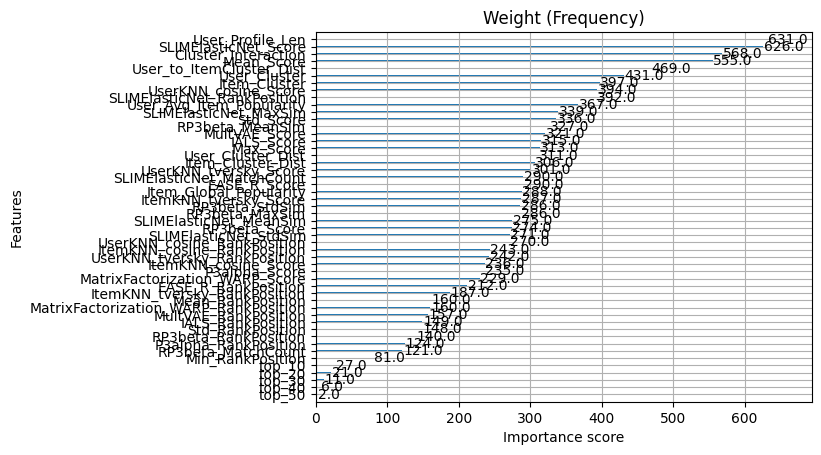

In [19]:
plot_importance(XGB_model, importance_type='weight', title='Weight (Frequency)')

<Axes: title={'center': 'Gain'}, xlabel='Importance score', ylabel='Features'>

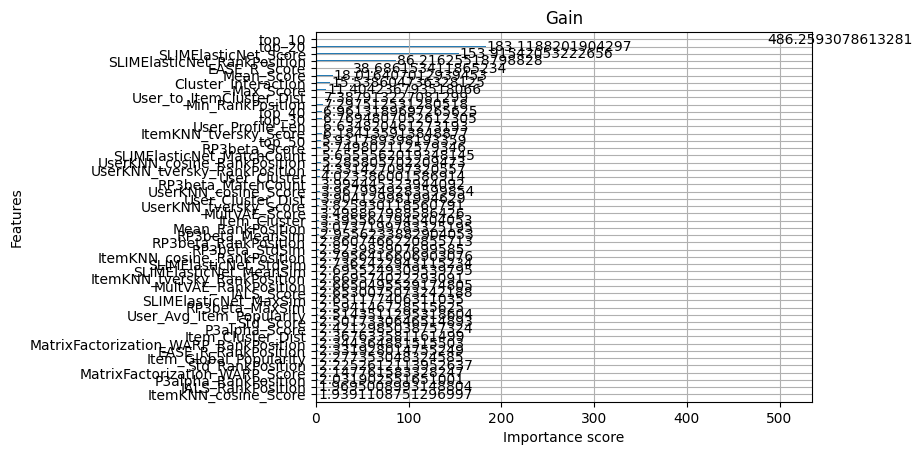

In [20]:
plot_importance(XGB_model, importance_type='gain', title='Gain')

<Axes: title={'center': 'Cover'}, xlabel='Importance score', ylabel='Features'>

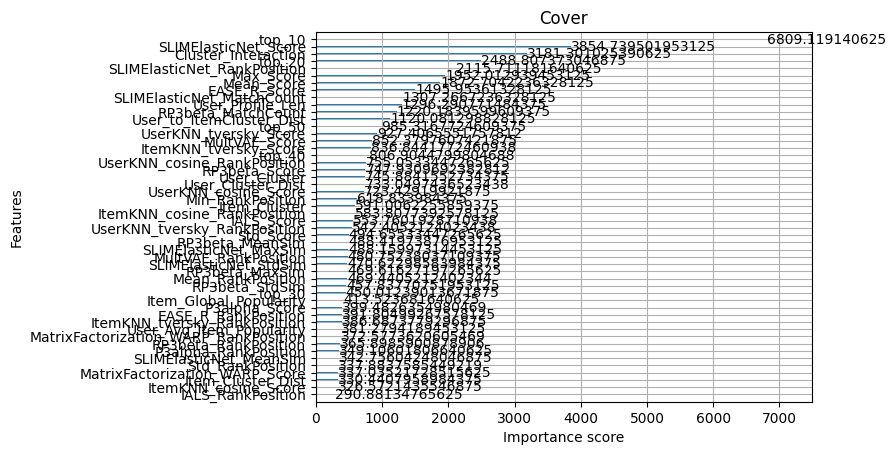

In [21]:
plot_importance(XGB_model, importance_type='cover', title='Cover')